<a href="https://colab.research.google.com/github/Gbsvani-10/Solar_Power_Forecasting_and_Fault_Detection/blob/main/Solar_Power_Forecasting_and_Fault_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

generation = pd.read_csv("Plant_1_Generation_Data.csv")

weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

print("Generation data shape:", generation.shape)
print("Weather data shape:", weather.shape)

Generation data shape: (68778, 7)
Weather data shape: (3182, 6)


In [ ]:
generation["DATE_TIME"] = pd.to_datetime(
    generation["DATE_TIME"],
    dayfirst=True
)

weather["DATE_TIME"] = pd.to_datetime(
    weather["DATE_TIME"]
)

print("Generation date range:")
print(generation["DATE_TIME"].min(), "to", generation["DATE_TIME"].max())

print("\nWeather date range:")
print(weather["DATE_TIME"].min(), "to", weather["DATE_TIME"].max())

Generation date range:
2020-05-15 00:00:00 to 2020-06-17 23:45:00

Weather date range:
2020-05-15 00:00:00 to 2020-06-17 23:45:00


In [ ]:
data = pd.merge(
    generation,
    weather,
    on="DATE_TIME",
    how="inner",
    suffixes=("_gen", "_weather")
)

print("Merged data shape:", data.shape)

print("\nMerged columns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
print(data.head())

Merged data shape: (68774, 12)

Merged columns:
['DATE_TIME', 'PLANT_ID_gen', 'SOURCE_KEY_gen', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID_weather', 'SOURCE_KEY_weather', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

First 5 rows:
   DATE_TIME  PLANT_ID_gen   SOURCE_KEY_gen  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15       4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15       4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15       4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15       4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15       4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  PLANT_ID_weather SOURCE_KEY_weather  AMBIENT_TEMPERATURE  \
0    6259559.0           4135001    HmiyD2TTLFNqkNe            25.184316   
1    6183645.0           4135001    HmiyD2TTLFNqkNe            25.184316   
2    6987759.0          

In [ ]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
DATE_TIME              0
PLANT_ID_gen           0
SOURCE_KEY_gen         0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_weather       0
SOURCE_KEY_weather     0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [ ]:
'''print("Number of unique inverters:")
print(data["SOURCE_KEY_gen"].nunique())

print("\nInverters:")
print(data["SOURCE_KEY_gen"].unique())'''
data = data.rename(columns={
    "PLANT_ID_gen": "PLANT_ID",
    "SOURCE_KEY_gen": "SOURCE_KEY"
})

print(data.columns.tolist())

['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID_weather', 'SOURCE_KEY_weather', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [ ]:
print("Number of unique inverters:")
print(data["SOURCE_KEY"].nunique())

print("\nInverters:")
print(data["SOURCE_KEY"].unique())

Number of unique inverters:
22

Inverters:
['1BY6WEcLGh8j5v7' '1IF53ai7Xc0U56Y' '3PZuoBAID5Wc2HD' '7JYdWkrLSPkdwr4'
 'McdE0feGgRqW7Ca' 'VHMLBKoKgIrUVDU' 'WRmjgnKYAwPKWDb' 'ZnxXDlPa8U1GXgE'
 'ZoEaEvLYb1n2sOq' 'adLQvlD726eNBSB' 'bvBOhCH3iADSZry' 'iCRJl6heRkivqQ3'
 'ih0vzX44oOqAx2f' 'pkci93gMrogZuBj' 'rGa61gmuvPhdLxV' 'sjndEbLyjtCKgGv'
 'uHbuxQJl8lW7ozc' 'wCURE6d3bPkepu2' 'z9Y9gH1T5YWrNuG' 'zBIq5rxdHJRwDNY'
 'zVJPv84UY57bAof' 'YxYtjZvoooNbGkE']


In [ ]:
print(data[[
    "DATE_TIME",
    "SOURCE_KEY",
    "DC_POWER",
    "AC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]].head())

   DATE_TIME       SOURCE_KEY  DC_POWER  AC_POWER  AMBIENT_TEMPERATURE  \
0 2020-05-15  1BY6WEcLGh8j5v7       0.0       0.0            25.184316   
1 2020-05-15  1IF53ai7Xc0U56Y       0.0       0.0            25.184316   
2 2020-05-15  3PZuoBAID5Wc2HD       0.0       0.0            25.184316   
3 2020-05-15  7JYdWkrLSPkdwr4       0.0       0.0            25.184316   
4 2020-05-15  McdE0feGgRqW7Ca       0.0       0.0            25.184316   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.857507          0.0  
2           22.857507          0.0  
3           22.857507          0.0  
4           22.857507          0.0  


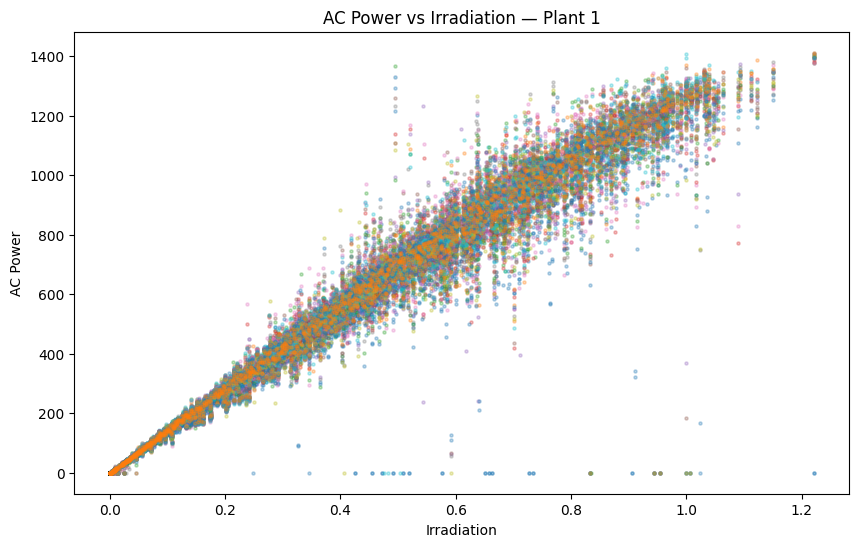

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for inverter in data["SOURCE_KEY"].unique():
    inverter_data = data[data["SOURCE_KEY"] == inverter]

    plt.scatter(
        inverter_data["IRRADIATION"],
        inverter_data["AC_POWER"],
        s=5,
        alpha=0.3,
        label=inverter
    )

plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.title("AC Power vs Irradiation — Plant 1")
plt.show()

In [ ]:
print("DC Power:")
print(data["DC_POWER"].describe())

print("\nAC Power:")
print(data["AC_POWER"].describe())

DC Power:
count    68774.000000
mean      3147.177450
std       4036.441826
min          0.000000
25%          0.000000
50%        428.571429
75%       6365.468750
max      14471.125000
Name: DC_POWER, dtype: float64

AC Power:
count    68774.000000
mean       307.778375
std        394.394865
min          0.000000
25%          0.000000
50%         41.450000
75%        623.561161
max       1410.950000
Name: AC_POWER, dtype: float64


In [ ]:
daylight = data[data["AC_POWER"] > 0].copy()

daylight["DC_AC_RATIO"] = (
    daylight["DC_POWER"] / daylight["AC_POWER"]
)

print("\nDC/AC ratio:")
print(daylight["DC_AC_RATIO"].describe())


DC/AC ratio:
count    36823.000000
mean        10.233666
std          0.048176
min          9.381550
25%         10.202579
50%         10.220237
75%         10.248117
max         10.465522
Name: DC_AC_RATIO, dtype: float64


In [ ]:
print("Total rows:", len(data))

print("Zero irradiation rows:")
print((data["IRRADIATION"] == 0).sum())

print("Positive irradiation rows:")
print((data["IRRADIATION"] > 0).sum())

Total rows: 68774
Zero irradiation rows:
30398
Positive irradiation rows:
38376


In [ ]:
# Keep only daylight observations
daylight = data[data["IRRADIATION"] > 0].copy()

print("Original rows:", len(data))
print("Daylight rows:", len(daylight))

print("\nDaylight data:")
print(daylight[[
    "DATE_TIME",
    "SOURCE_KEY",
    "AC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]].head())

Original rows: 68774
Daylight rows: 38376

Daylight data:
              DATE_TIME       SOURCE_KEY  AC_POWER  AMBIENT_TEMPERATURE  \
489 2020-05-15 05:45:00  1BY6WEcLGh8j5v7       0.0            24.289211   
490 2020-05-15 05:45:00  1IF53ai7Xc0U56Y       0.0            24.289211   
491 2020-05-15 05:45:00  3PZuoBAID5Wc2HD       0.0            24.289211   
492 2020-05-15 05:45:00  7JYdWkrLSPkdwr4       0.0            24.289211   
493 2020-05-15 05:45:00  McdE0feGgRqW7Ca       0.0            24.289211   

     MODULE_TEMPERATURE  IRRADIATION  
489           23.096692     0.000863  
490           23.096692     0.000863  
491           23.096692     0.000863  
492           23.096692     0.000863  
493           23.096692     0.000863  


In [ ]:
daylight["HOUR"] = daylight["DATE_TIME"].dt.hour + (
    daylight["DATE_TIME"].dt.minute / 60
)

print(daylight[[
    "DATE_TIME",
    "HOUR",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "AC_POWER"
]].head())

              DATE_TIME  HOUR  IRRADIATION  MODULE_TEMPERATURE  \
489 2020-05-15 05:45:00  5.75     0.000863           23.096692   
490 2020-05-15 05:45:00  5.75     0.000863           23.096692   
491 2020-05-15 05:45:00  5.75     0.000863           23.096692   
492 2020-05-15 05:45:00  5.75     0.000863           23.096692   
493 2020-05-15 05:45:00  5.75     0.000863           23.096692   

     AMBIENT_TEMPERATURE  AC_POWER  
489            24.289211       0.0  
490            24.289211       0.0  
491            24.289211       0.0  
492            24.289211       0.0  
493            24.289211       0.0  


In [ ]:
features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR"
]

target = "AC_POWER"

print("Features:")
print(features)

print("\nTarget:")
print(target)

print("\nMissing values:")
print(daylight[features + [target]].isnull().sum())

Features:
['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE', 'HOUR']

Target:
AC_POWER

Missing values:
IRRADIATION            0
MODULE_TEMPERATURE     0
AMBIENT_TEMPERATURE    0
HOUR                   0
AC_POWER               0
dtype: int64


In [ ]:
# Create a date column
daylight["DATE"] = daylight["DATE_TIME"].dt.date

# Get all available dates
dates = sorted(daylight["DATE"].unique())

print("Number of days:", len(dates))
print("Dates:")
print(dates)

Number of days: 34
Dates:
[datetime.date(2020, 5, 15), datetime.date(2020, 5, 16), datetime.date(2020, 5, 17), datetime.date(2020, 5, 18), datetime.date(2020, 5, 19), datetime.date(2020, 5, 20), datetime.date(2020, 5, 21), datetime.date(2020, 5, 22), datetime.date(2020, 5, 23), datetime.date(2020, 5, 24), datetime.date(2020, 5, 25), datetime.date(2020, 5, 26), datetime.date(2020, 5, 27), datetime.date(2020, 5, 28), datetime.date(2020, 5, 29), datetime.date(2020, 5, 30), datetime.date(2020, 5, 31), datetime.date(2020, 6, 1), datetime.date(2020, 6, 2), datetime.date(2020, 6, 3), datetime.date(2020, 6, 4), datetime.date(2020, 6, 5), datetime.date(2020, 6, 6), datetime.date(2020, 6, 7), datetime.date(2020, 6, 8), datetime.date(2020, 6, 9), datetime.date(2020, 6, 10), datetime.date(2020, 6, 11), datetime.date(2020, 6, 12), datetime.date(2020, 6, 13), datetime.date(2020, 6, 14), datetime.date(2020, 6, 15), datetime.date(2020, 6, 16), datetime.date(2020, 6, 17)]


In [ ]:
# Use the last 20% of days for testing
split_index = int(len(dates) * 0.8)

train_dates = dates[:split_index]
test_dates = dates[split_index:]

train = daylight[daylight["DATE"].isin(train_dates)].copy()
test = daylight[daylight["DATE"].isin(test_dates)].copy()

print("Training days:", len(train_dates))
print("Testing days:", len(test_dates))

print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(train["DATE_TIME"].min(), "to", train["DATE_TIME"].max())

print("\nTesting period:")
print(test["DATE_TIME"].min(), "to", test["DATE_TIME"].max())

Training days: 27
Testing days: 7
Training rows: 30280
Testing rows: 8096

Training period:
2020-05-15 05:45:00 to 2020-06-10 18:30:00

Testing period:
2020-06-11 06:00:00 to 2020-06-17 18:45:00


In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (30280, 4)
y_train: (30280,)
X_test: (8096, 4)
y_test: (8096,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:")
print(X_train_scaled[:5])

print("\nScaled testing data:")
print(X_test_scaled[:5])

Scaled training data:
[[-1.42763371 -1.43609815 -1.06351388 -1.71409084]
 [-1.42763371 -1.43609815 -1.06351388 -1.71409084]
 [-1.42763371 -1.43609815 -1.06351388 -1.71409084]
 [-1.42763371 -1.43609815 -1.06351388 -1.71409084]
 [-1.42763371 -1.43609815 -1.06351388 -1.71409084]]

Scaled testing data:
[[-1.42221714 -1.66296405 -1.80509455 -1.64760444]
 [-1.42221714 -1.66296405 -1.80509455 -1.64760444]
 [-1.42221714 -1.66296405 -1.80509455 -1.64760444]
 [-1.42221714 -1.66296405 -1.80509455 -1.64760444]
 [-1.42221714 -1.66296405 -1.80509455 -1.64760444]]


In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_scaled, y_train)

print("MLP training completed.")

MLP training completed.


In [ ]:
y_pred = mlp.predict(X_test_scaled)

print("First 10 actual values:")
print(y_test.values[:10])

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 predicted values:
[3.49725648 3.49725648 3.49725648 3.49725648 3.49725648 3.49725648
 3.49725648 3.49725648 3.49725648 3.49725648]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model A Results")
print("MAE =", round(mae, 4))
print("R²  =", round(r2, 4))

Model A Results
MAE = 26.4379
R²  = 0.964


In [ ]:
test_results = test.copy()

test_results["PREDICTED_AC"] = y_pred

test_results["ERROR"] = (
    test_results["AC_POWER"] - test_results["PREDICTED_AC"]
)

test_results["ABS_ERROR"] = (
    test_results["ERROR"].abs()
)

print(test_results[[
    "DATE_TIME",
    "SOURCE_KEY",
    "AC_POWER",
    "PREDICTED_AC",
    "ERROR"
]].head(10))

                DATE_TIME       SOURCE_KEY  AC_POWER  PREDICTED_AC     ERROR
54562 2020-06-11 06:00:00  1BY6WEcLGh8j5v7       0.0      3.497256 -3.497256
54563 2020-06-11 06:00:00  1IF53ai7Xc0U56Y       0.0      3.497256 -3.497256
54564 2020-06-11 06:00:00  3PZuoBAID5Wc2HD       0.0      3.497256 -3.497256
54565 2020-06-11 06:00:00  7JYdWkrLSPkdwr4       0.0      3.497256 -3.497256
54566 2020-06-11 06:00:00  McdE0feGgRqW7Ca       0.0      3.497256 -3.497256
54567 2020-06-11 06:00:00  VHMLBKoKgIrUVDU       0.0      3.497256 -3.497256
54568 2020-06-11 06:00:00  WRmjgnKYAwPKWDb       0.0      3.497256 -3.497256
54569 2020-06-11 06:00:00  YxYtjZvoooNbGkE       0.0      3.497256 -3.497256
54570 2020-06-11 06:00:00  ZnxXDlPa8U1GXgE       0.0      3.497256 -3.497256
54571 2020-06-11 06:00:00  ZoEaEvLYb1n2sOq       0.0      3.497256 -3.497256


In [ ]:
inverter_performance = (
    test_results
    .groupby("SOURCE_KEY")
    .agg(
        mean_error=("ERROR", "mean"),
        mean_abs_error=("ABS_ERROR", "mean"),
        actual_mean=("AC_POWER", "mean"),
        predicted_mean=("PREDICTED_AC", "mean")
    )
    .sort_values("mean_error")
)

print(inverter_performance)

                 mean_error  mean_abs_error  actual_mean  predicted_mean
SOURCE_KEY                                                              
bvBOhCH3iADSZry  -63.445499       67.939545   432.543699      495.989197
1BY6WEcLGh8j5v7  -58.409878       64.378704   437.579320      495.989197
ih0vzX44oOqAx2f   -4.591814       18.349901   491.397384      495.989197
YxYtjZvoooNbGkE   -0.496646       17.788759   495.492551      495.989197
ZoEaEvLYb1n2sOq   -0.417460       17.268401   495.571737      495.989197
zBIq5rxdHJRwDNY    1.681448       24.323334   497.670645      495.989197
z9Y9gH1T5YWrNuG    3.058703       20.988766   499.047900      495.989197
7JYdWkrLSPkdwr4    3.886084       20.238580   499.875281      495.989197
WRmjgnKYAwPKWDb    3.899580       28.034064   499.888777      495.989197
pkci93gMrogZuBj    4.366711       21.850217   500.355908      495.989197
rGa61gmuvPhdLxV    5.830548       20.125913   501.819746      495.989197
zVJPv84UY57bAof    6.009652       20.031400   501.9

In [ ]:
worst_inverter = inverter_performance.index[0]

print("Worst-performing inverter:")
print(worst_inverter)

print("\nPerformance:")
print(inverter_performance.loc[worst_inverter])

Worst-performing inverter:
bvBOhCH3iADSZry

Performance:
mean_error        -63.445499
mean_abs_error     67.939545
actual_mean       432.543699
predicted_mean    495.989197
Name: bvBOhCH3iADSZry, dtype: float64


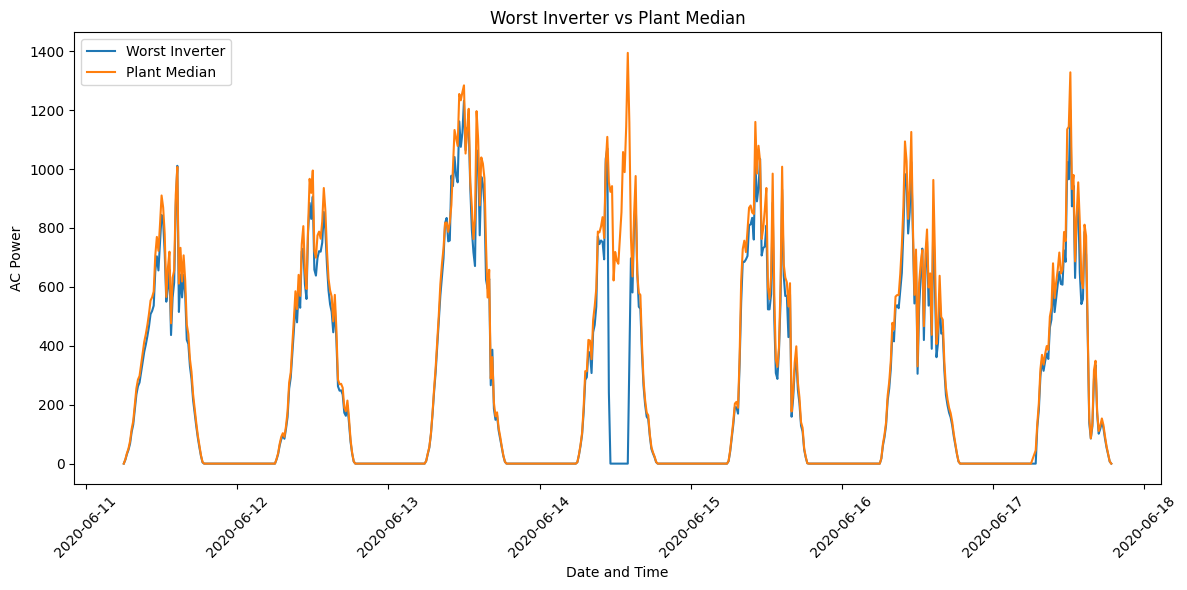

In [ ]:
worst_data = test_results[
    test_results["SOURCE_KEY"] == worst_inverter
].copy()

plant_median = (
    test_results
    .groupby("DATE_TIME")["AC_POWER"]
    .median()
    .reset_index(name="PLANT_MEDIAN_AC")
)

worst_data = worst_data.merge(
    plant_median,
    on="DATE_TIME",
    how="left"
)

plt.figure(figsize=(12, 6))

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["AC_POWER"],
    label="Worst Inverter"
)

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["PLANT_MEDIAN_AC"],
    label="Plant Median"
)

plt.xlabel("Date and Time")
plt.ylabel("AC Power")
plt.title("Worst Inverter vs Plant Median")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Create plant-level AC power
plant = (
    data.groupby("DATE_TIME")
    .agg(
        PLANT_AC_POWER=("AC_POWER", "sum"),
        IRRADIATION=("IRRADIATION", "first"),
        MODULE_TEMPERATURE=("MODULE_TEMPERATURE", "first"),
        AMBIENT_TEMPERATURE=("AMBIENT_TEMPERATURE", "first")
    )
    .reset_index()
)

print("Plant data shape:", plant.shape)

print("\nFirst 5 rows:")
print(plant.head())

Plant data shape: (3157, 5)

First 5 rows:
            DATE_TIME  PLANT_AC_POWER  IRRADIATION  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00             0.0          0.0           22.857507   
1 2020-05-15 00:15:00             0.0          0.0           22.761668   
2 2020-05-15 00:30:00             0.0          0.0           22.592306   
3 2020-05-15 00:45:00             0.0          0.0           22.360852   
4 2020-05-15 01:00:00             0.0          0.0           22.165423   

   AMBIENT_TEMPERATURE  
0            25.184316  
1            25.084589  
2            24.935753  
3            24.846130  
4            24.621525  


In [ ]:
plant["HOUR"] = plant["DATE_TIME"].dt.hour
plant["MINUTE"] = plant["DATE_TIME"].dt.minute

plant["TIME_INDEX"] = (
    plant["HOUR"] * 4 + plant["MINUTE"] // 15
)

print(plant.head())

            DATE_TIME  PLANT_AC_POWER  IRRADIATION  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00             0.0          0.0           22.857507   
1 2020-05-15 00:15:00             0.0          0.0           22.761668   
2 2020-05-15 00:30:00             0.0          0.0           22.592306   
3 2020-05-15 00:45:00             0.0          0.0           22.360852   
4 2020-05-15 01:00:00             0.0          0.0           22.165423   

   AMBIENT_TEMPERATURE  HOUR  MINUTE  TIME_INDEX  
0            25.184316     0       0           0  
1            25.084589     0      15           1  
2            24.935753     0      30           2  
3            24.846130     0      45           3  
4            24.621525     1       0           4  


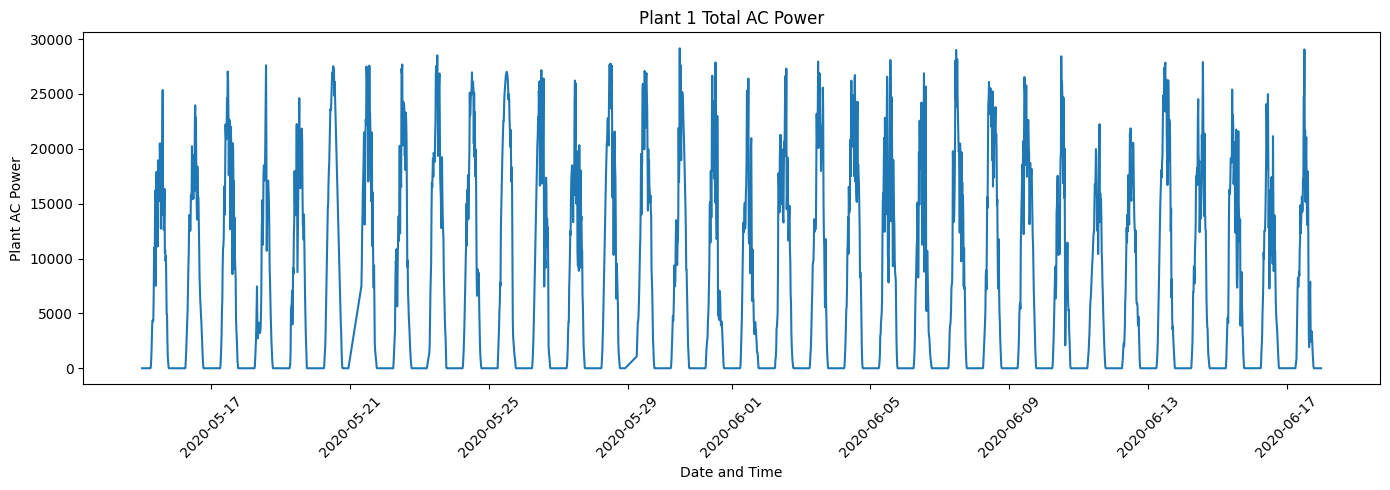

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    plant["DATE_TIME"],
    plant["PLANT_AC_POWER"]
)

plt.xlabel("Date and Time")
plt.ylabel("Plant AC Power")
plt.title("Plant 1 Total AC Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Features used by the forecasting model
forecast_features = [
    "PLANT_AC_POWER",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE"
]

print("Forecast features:")
print(forecast_features)

print("\nMissing values:")
print(plant[forecast_features].isnull().sum())

Forecast features:
['PLANT_AC_POWER', 'IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']

Missing values:
PLANT_AC_POWER         0
IRRADIATION            0
MODULE_TEMPERATURE     0
AMBIENT_TEMPERATURE    0
dtype: int64


In [ ]:
input_steps = 16
output_steps = 4

X = []
y = []

values = plant[forecast_features].values

for i in range(len(values) - input_steps - output_steps + 1):

    X.append(
        values[i:i + input_steps]
    )

    y.append(
        values[
            i + input_steps:
            i + input_steps + output_steps,
            0
        ]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3138, 16, 4)
y shape: (3138, 4)


In [ ]:
# Time-based train/test split
split_index = int(len(plant) * 0.8)

train_plant = plant.iloc[:split_index].copy()
test_plant = plant.iloc[split_index:].copy()

print("Training rows:", len(train_plant))
print("Testing rows:", len(test_plant))

print("\nTraining period:")
print(train_plant["DATE_TIME"].min(), "to", train_plant["DATE_TIME"].max())

print("\nTesting period:")
print(test_plant["DATE_TIME"].min(), "to", test_plant["DATE_TIME"].max())

Training rows: 2525
Testing rows: 632

Training period:
2020-05-15 00:00:00 to 2020-06-11 09:15:00

Testing period:
2020-06-11 09:30:00 to 2020-06-17 23:45:00


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_values = scaler.fit_transform(
    train_plant[forecast_features]
)

test_values = scaler.transform(
    test_plant[forecast_features]
)

print("Scaled training shape:", train_values.shape)
print("Scaled testing shape:", test_values.shape)

Scaled training shape: (2525, 4)
Scaled testing shape: (632, 4)


In [ ]:
# Number of previous and future time steps
input_steps = 16      # previous 4 hours
output_steps = 4      # next 1 hour


def create_sequences(values, input_steps, output_steps):

    X = []
    y = []

    for i in range(len(values) - input_steps - output_steps + 1):

        # Previous 16 time steps
        X.append(
            values[i:i + input_steps]
        )

        # Next 4 plant AC power values
        y.append(
            values[
                i + input_steps:
                i + input_steps + output_steps,
                0
            ]
        )

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(
    train_values,
    input_steps,
    output_steps
)

X_test, y_test = create_sequences(
    test_values,
    input_steps,
    output_steps
)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2506, 16, 4)
y_train shape: (2506, 4)
X_test shape: (613, 16, 4)
y_test shape: (613, 4)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(4)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,876 (77.64 KB)

 Trainable params: 19,876 (77.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0356 - val_loss: 0.0120
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0147 - val_loss: 0.0109
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0134 - val_loss: 0.0102
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0131 - val_loss: 0.0099
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0123 - val_loss: 0.0096
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - val_loss: 0.0096
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0114 - val_loss: 0.0089
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0114 - val_loss: 0.0098
Epoch 9/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0114 - val_loss: 0.0086
Epoch 10/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0109 - val_loss: 0.0093
Epoch 11/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106 - val_loss: 0.0085
Epoch 12/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0107 - val

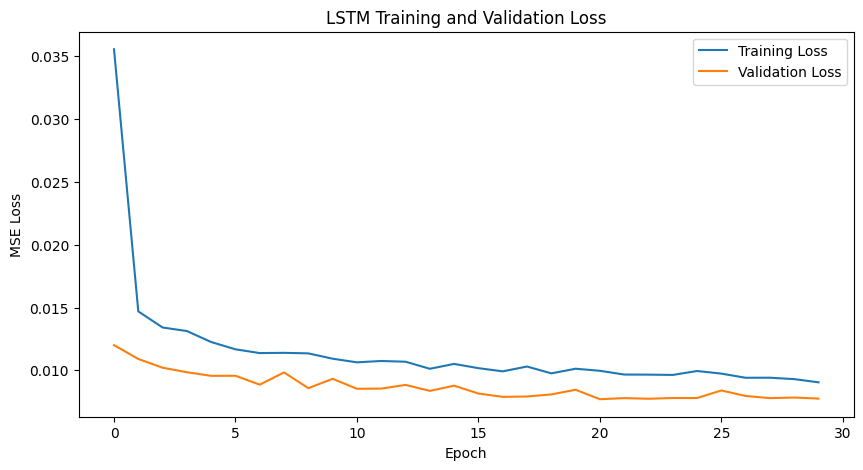

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
y_pred_scaled = model.predict(X_test)

print("Prediction shape:", y_pred_scaled.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Prediction shape: (613, 4)


In [ ]:
# Convert scaled predictions back to original AC power

ac_min = scaler.data_min_[0]
ac_max = scaler.data_max_[0]

y_pred = y_pred_scaled * (ac_max - ac_min) + ac_min
y_actual = y_test * (ac_max - ac_min) + ac_min

print("First actual 4 values:")
print(y_actual[0])

print("\nFirst predicted 4 values:")
print(y_pred[0])

First actual 4 values:
[10412.4285715 13812.7107143 14541.3357143 20225.8785719]

First predicted 4 values:
[16425.97756904 17326.67921751 17711.73263418 17115.61090533]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(
    y_actual.flatten(),
    y_pred.flatten()
)

r2 = r2_score(
    y_actual.flatten(),
    y_pred.flatten()
)

print("Model B LSTM Results")
print("MAE =", round(mae, 4))
print("R²  =", round(r2, 4))

Model B LSTM Results
MAE = 1547.3464
R²  = 0.8814


In [ ]:
# Persistence baseline:
# Assume all next 4 values are equal to the last observed AC power

persistence_pred = np.repeat(
    X_test[:, -1, 0].reshape(-1, 1),
    4,
    axis=1
)

# Convert from scaled to original AC power
persistence_pred = (
    persistence_pred * (ac_max - ac_min) + ac_min
)

persistence_mae = mean_absolute_error(
    y_actual.flatten(),
    persistence_pred.flatten()
)

persistence_r2 = r2_score(
    y_actual.flatten(),
    persistence_pred.flatten()
)

print("Persistence Baseline")
print("MAE =", round(persistence_mae, 4))
print("R²  =", round(persistence_r2, 4))

Persistence Baseline
MAE = 1812.3053
R²  = 0.8361


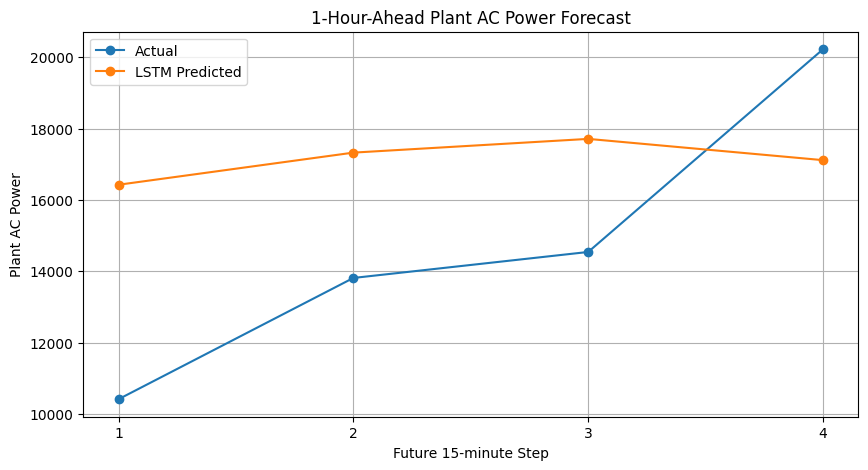

In [ ]:
import matplotlib.pyplot as plt

# Take the first test sequence
actual = y_actual[0]
predicted = y_pred[0]

future_steps = [1, 2, 3, 4]

plt.figure(figsize=(10, 5))

plt.plot(
    future_steps,
    actual,
    marker="o",
    label="Actual"
)

plt.plot(
    future_steps,
    predicted,
    marker="o",
    label="LSTM Predicted"
)

plt.xlabel("Future 15-minute Step")
plt.ylabel("Plant AC Power")
plt.title("1-Hour-Ahead Plant AC Power Forecast")
plt.xticks(future_steps)
plt.legend()
plt.grid(True)

plt.show()

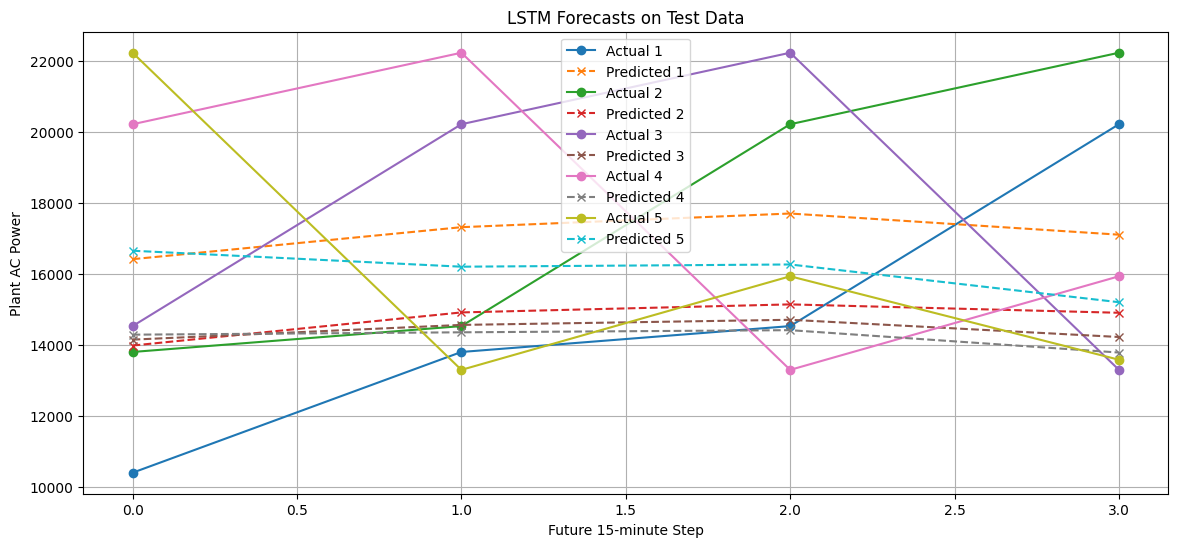

In [ ]:
plt.figure(figsize=(14, 6))

for i in range(5):
    plt.plot(
        range(4),
        y_actual[i],
        marker="o",
        label=f"Actual {i+1}"
    )

    plt.plot(
        range(4),
        y_pred[i],
        marker="x",
        linestyle="--",
        label=f"Predicted {i+1}"
    )

plt.xlabel("Future 15-minute Step")
plt.ylabel("Plant AC Power")
plt.title("LSTM Forecasts on Test Data")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("Comparison")
print("------------------------------")
print("LSTM MAE        :", round(mae, 4))
print("Persistence MAE:", round(persistence_mae, 4))

if mae < persistence_mae:
    print("\nLSTM performs better than persistence.")
else:
    print("\nPersistence performs better than LSTM.")

Comparison
------------------------------
LSTM MAE        : 1547.3464
Persistence MAE: 1812.3053

LSTM performs better than persistence.


In [ ]:
import pandas as pd
import numpy as np

generation2 = pd.read_csv("Plant_2_Generation_Data.csv")
weather2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

print("Generation 2 shape:", generation2.shape)
print("Weather 2 shape:", weather2.shape)

Generation 2 shape: (67698, 7)
Weather 2 shape: (3259, 6)


In [ ]:
generation2["DATE_TIME"] = pd.to_datetime(
    generation2["DATE_TIME"],
    dayfirst=True
)

weather2["DATE_TIME"] = pd.to_datetime(
    weather2["DATE_TIME"]
)

print(
    generation2["DATE_TIME"].min(),
    "to",
    generation2["DATE_TIME"].max()
)

print(
    weather2["DATE_TIME"].min(),
    "to",
    weather2["DATE_TIME"].max()
)

2020-05-15 00:00:00 to 2020-06-17 23:45:00
2020-05-15 00:00:00 to 2020-06-17 23:45:00


/tmp/ipykernel_336/1316496174.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  generation2["DATE_TIME"] = pd.to_datetime(


In [ ]:
data2 = pd.merge(
    generation2,
    weather2,
    on="DATE_TIME",
    how="inner",
    suffixes=("_gen", "_weather")
)

data2 = data2.rename(columns={
    "PLANT_ID_gen": "PLANT_ID",
    "SOURCE_KEY_gen": "SOURCE_KEY"
})

print("Merged Plant 2 shape:", data2.shape)
print(data2.columns.tolist())

Merged Plant 2 shape: (67698, 12)
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID_weather', 'SOURCE_KEY_weather', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [ ]:
data2["HOUR"] = data2["DATE_TIME"].dt.hour

daylight2 = data2[data2["AC_POWER"] > 0].copy()

features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR"
]

target = "AC_POWER"

print("Plant 2 daylight rows:", len(daylight2))
print("Missing values:")
print(daylight2[features + [target]].isnull().sum())

Plant 2 daylight rows: 32036
Missing values:
IRRADIATION            0
MODULE_TEMPERATURE     0
AMBIENT_TEMPERATURE    0
HOUR                   0
AC_POWER               0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Model A features
features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR"
]

target = "AC_POWER"

# Create the correct scaler for Model A
modelA_scaler = StandardScaler()

# Fit ONLY on Plant 1 training data
modelA_scaler.fit(train[features])

# Transform Plant 2 using Plant 1's scaler
X2 = daylight2[features]
y2 = daylight2[target]

X2_scaled = modelA_scaler.transform(X2)

print("Plant 2 input shape:", X2_scaled.shape)

Plant 2 input shape: (32036, 4)


In [ ]:
y2_pred = mlp.predict(X2_scaled)

print("Plant 2 predictions completed.")

print("\nFirst 10 actual values:")
print(y2.values[:10])

print("\nFirst 10 predicted values:")
print(y2_pred[:10])

Plant 2 predictions completed.

First 10 actual values:
[14.86       14.24666667 14.84       14.44       14.63333333 15.02
 14.67333333 14.58666667 14.45333333 13.99333333]

First 10 predicted values:
[22.32366116 22.32366116 22.32366116 22.32366116 22.32366116 22.32366116
 22.32366116 22.32366116 22.32366116 22.32366116]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae2 = mean_absolute_error(y2, y2_pred)
r2_2 = r2_score(y2, y2_pred)

print("\nPlant 2 Transfer Results")
print("MAE =", round(mae2, 4))
print("R²  =", round(r2_2, 4))


Plant 2 Transfer Results
MAE = 54.9953
R²  = 0.8859


In [ ]:
print("\n===== PLANT 1 vs PLANT 2 =====")

print("Plant 1 MAE =", round(mae, 4))
print("Plant 1 R²  =", round(r2, 4))

print("Plant 2 MAE =", round(mae2, 4))
print("Plant 2 R²  =", round(r2_2, 4))


===== PLANT 1 vs PLANT 2 =====
Plant 1 MAE = 1547.3464
Plant 1 R²  = 0.8814
Plant 2 MAE = 54.9953
Plant 2 R²  = 0.8859


In [ ]:
if r2_2 >= 0.8:
    print("\nConclusion: The Plant 1 model transfers reasonably well to Plant 2.")
elif r2_2 >= 0.5:
    print("\nConclusion: The Plant 1 model transfers moderately well to Plant 2.")
else:
    print("\nConclusion: The Plant 1 model does not transfer well to Plant 2.")


Conclusion: The Plant 1 model transfers reasonably well to Plant 2.


In [ ]:
print("Unique predictions:", len(np.unique(y2_pred)))

print("Prediction minimum:", y2_pred.min())
print("Prediction maximum:", y2_pred.max())
print("Prediction mean:", y2_pred.mean())

print("\nActual minimum:", y2.min())
print("Actual maximum:", y2.max())
print("Actual mean:", y2.mean())

Unique predictions: 1726
Prediction minimum: 4.048622226542419
Prediction maximum: 1342.3736541419505
Prediction mean: 516.7365793614063

Actual minimum: 0.2714285714285714
Actual maximum: 1385.42
Actual mean: 509.8647212651511


In [ ]:
# Predict the next 1 hour (4 steps) on the test set

y_pred_lstm = model.predict(X_test)

print("LSTM prediction shape:", y_pred_lstm.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
LSTM prediction shape: (613, 4)


In [ ]:
from sklearn.metrics import mean_absolute_error

lstm_mae = mean_absolute_error(
    y_test.flatten(),
    y_pred_lstm.flatten()
)

print("LSTM MAE =", round(lstm_mae, 4))

LSTM MAE = 0.0531


In [ ]:
# Last plant AC power in each input sequence
persistence_pred = X_test[:, -1, 0]

# Repeat the same value for all 4 future steps
persistence_pred = np.repeat(
    persistence_pred.reshape(-1, 1),
    4,
    axis=1
)

persistence_mae = mean_absolute_error(
    y_test.flatten(),
    persistence_pred.flatten()
)

print("Persistence MAE =", round(persistence_mae, 4))

Persistence MAE = 0.0622


In [ ]:
print("\n===== FORECAST COMPARISON =====")
print("LSTM MAE        =", round(lstm_mae, 4))
print("Persistence MAE =", round(persistence_mae, 4))

if lstm_mae < persistence_mae:
    print("LSTM performs better than the persistence baseline.")
else:
    print("Persistence performs better than the LSTM.")


===== FORECAST COMPARISON =====
LSTM MAE        = 0.0531
Persistence MAE = 0.0622
LSTM performs better than the persistence baseline.


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Generation_Data.csv', 'Plant_1_Generation_Data.csv', 'Plant_2_Weather_Sensor_Data.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

generation = pd.read_csv("/content/Plant_1_Generation_Data.csv")
weather = pd.read_csv("/content/Plant_1_Weather_Sensor_Data.csv")

generation["DATE_TIME"] = pd.to_datetime(
    generation["DATE_TIME"],
    dayfirst=True
)

weather["DATE_TIME"] = pd.to_datetime(
    weather["DATE_TIME"]
)

data = pd.merge(
    generation,
    weather,
    on="DATE_TIME",
    how="inner",
    suffixes=("_gen", "_weather")
)

data = data.rename(columns={
    "PLANT_ID_gen": "PLANT_ID",
    "SOURCE_KEY_gen": "SOURCE_KEY"
})

data["HOUR"] = data["DATE_TIME"].dt.hour
data["DATE"] = data["DATE_TIME"].dt.date

print("Plant 1 merged data shape:", data.shape)
print("Number of inverters:", data["SOURCE_KEY"].nunique())

Plant 1 merged data shape: (68774, 14)
Number of inverters: 22


In [ ]:
# Create Plant 1 daylight data

daylight = data[data["AC_POWER"] > 0].copy()

# Create date column
daylight["DATE"] = daylight["DATE_TIME"].dt.date

# Get all available days
dates = sorted(daylight["DATE"].unique())

# Last 20% of days for testing
split_index = int(len(dates) * 0.8)

train_dates = dates[:split_index]
test_dates = dates[split_index:]

train = daylight[daylight["DATE"].isin(train_dates)].copy()
test = daylight[daylight["DATE"].isin(test_dates)].copy()

print("Training days:", len(train_dates))
print("Testing days:", len(test_dates))
print("Training rows:", len(train))
print("Testing rows:", len(test))

Training days: 27
Testing days: 7
Training rows: 29119
Testing rows: 7704


In [ ]:
# Model A features
features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR"
]

target = "AC_POWER"

# Check whether the trained MLP still exists
print("MLP exists:", "mlp" in globals())
print("Scaler exists:", "modelA_scaler" in globals())

MLP exists: False
Scaler exists: False


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR"
]

target = "AC_POWER"

# Prepare training and testing data
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Scale features using ONLY training data
modelA_scaler = StandardScaler()

X_train_scaled = modelA_scaler.fit_transform(X_train)
X_test_scaled = modelA_scaler.transform(X_test)

# Train MLP
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_scaled, y_train)

print("Model A trained successfully.")

Model A trained successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = mlp.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model A Results")
print("MAE =", round(mae, 4))
print("R²  =", round(r2, 4))

Model A Results
MAE = 26.2533
R²  = 0.9831


In [ ]:
test_results = test[
    ["DATE_TIME", "SOURCE_KEY", "AC_POWER"]
].copy()

test_results["PREDICTED_AC"] = y_pred

test_results["ERROR"] = (
    test_results["AC_POWER"] -
    test_results["PREDICTED_AC"]
)

test_results["ABS_ERROR"] = abs(
    test_results["ERROR"]
)

print(test_results.head())

                DATE_TIME       SOURCE_KEY   AC_POWER  PREDICTED_AC     ERROR  \
54584 2020-06-11 06:15:00  1BY6WEcLGh8j5v7  13.185714     22.428478 -9.242763   
54585 2020-06-11 06:15:00  1IF53ai7Xc0U56Y  14.500000     22.428478 -7.928478   
54586 2020-06-11 06:15:00  3PZuoBAID5Wc2HD  15.175000     22.428478 -7.253478   
54587 2020-06-11 06:15:00  7JYdWkrLSPkdwr4  14.400000     22.428478 -8.028478   
54588 2020-06-11 06:15:00  McdE0feGgRqW7Ca  14.542857     22.428478 -7.885621   

       ABS_ERROR  
54584   9.242763  
54585   7.928478  
54586   7.253478  
54587   8.028478  
54588   7.885621  


In [ ]:
inverter_performance = (
    test_results
    .groupby("SOURCE_KEY")
    .agg(
        mean_error=("ERROR", "mean"),
        mean_abs_error=("ABS_ERROR", "mean"),
        actual_mean=("AC_POWER", "mean"),
        predicted_mean=("PREDICTED_AC", "mean")
    )
    .sort_values("mean_error")
)

print(inverter_performance)

                 mean_error  mean_abs_error  actual_mean  predicted_mean
SOURCE_KEY                                                              
bvBOhCH3iADSZry  -34.920372       40.028693   470.935151      505.855523
1BY6WEcLGh8j5v7  -29.578922       36.517033   475.012359      504.591281
ih0vzX44oOqAx2f   -2.759289       19.027357   512.278292      515.037581
YxYtjZvoooNbGkE    1.607771       19.607282   519.490766      517.882995
ZoEaEvLYb1n2sOq    1.690792       19.322910   519.573787      517.882995
z9Y9gH1T5YWrNuG    5.335316       23.077961   523.218311      517.882995
7JYdWkrLSPkdwr4    6.202770       22.042290   524.085765      517.882995
WRmjgnKYAwPKWDb    6.216919       30.721728   524.099915      517.882995
pkci93gMrogZuBj    6.706675       24.905841   524.589670      517.882995
zBIq5rxdHJRwDNY    7.960672       23.065687   524.764463      516.803791
rGa61gmuvPhdLxV    8.241410       23.348243   526.124406      517.882995
zVJPv84UY57bAof    8.429188       23.540135   526.3

In [ ]:
worst_inverter = inverter_performance.index[0]

print("Worst-performing inverter:")
print(worst_inverter)

print("\nPerformance:")
print(inverter_performance.loc[worst_inverter])

Worst-performing inverter:
bvBOhCH3iADSZry

Performance:
mean_error        -34.920372
mean_abs_error     40.028693
actual_mean       470.935151
predicted_mean    505.855523
Name: bvBOhCH3iADSZry, dtype: float64


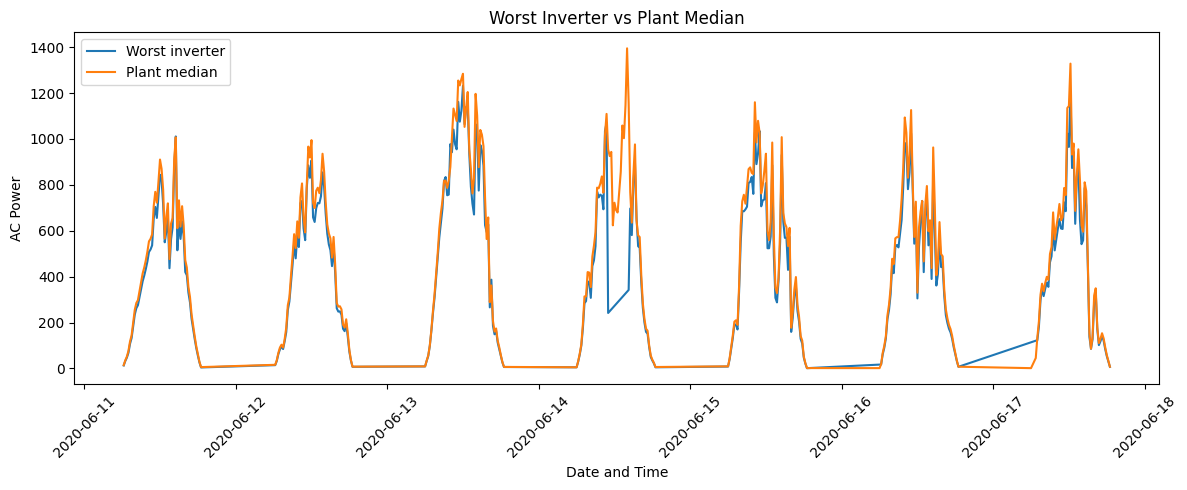

In [ ]:
import matplotlib.pyplot as plt

worst = "bvBOhCH3iADSZry"

# Worst inverter
worst_data = test_results[
    test_results["SOURCE_KEY"] == worst
].copy()

# Plant median at each timestamp
plant_median = (
    test_results
    .groupby("DATE_TIME")["AC_POWER"]
    .median()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["AC_POWER"],
    label="Worst inverter"
)

plt.plot(
    plant_median["DATE_TIME"],
    plant_median["AC_POWER"],
    label="Plant median"
)

plt.xlabel("Date and Time")
plt.ylabel("AC Power")
plt.title("Worst Inverter vs Plant Median")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

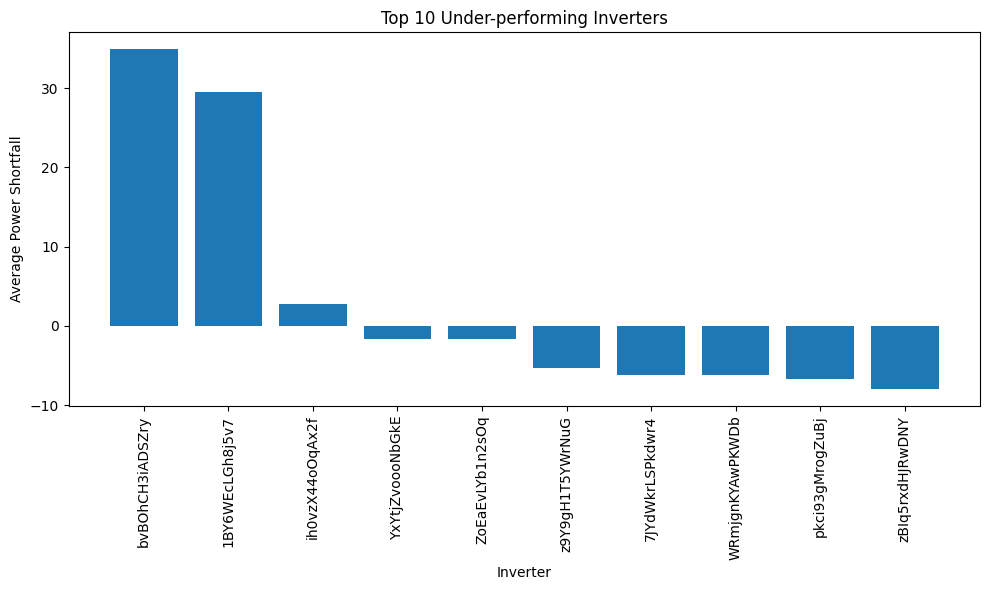

In [ ]:
top10 = inverter_performance.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10.index,
    -top10["mean_error"]
)

plt.xlabel("Inverter")
plt.ylabel("Average Power Shortfall")
plt.title("Top 10 Under-performing Inverters")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Generation_Data.csv', 'Plant_1_Generation_Data.csv', 'Plant_2_Weather_Sensor_Data.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Load Plant 1 files
generation = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

generation["DATE_TIME"] = pd.to_datetime(
    generation["DATE_TIME"],
    dayfirst=True
)

weather["DATE_TIME"] = pd.to_datetime(
    weather["DATE_TIME"]
)

# 2. Merge
data = pd.merge(
    generation,
    weather,
    on="DATE_TIME",
    how="inner",
    suffixes=("_gen", "_weather")
)

# 3. Create plant-level power
plant = (
    data.groupby("DATE_TIME")
    .agg(
        PLANT_AC_POWER=("AC_POWER", "sum"),
        IRRADIATION=("IRRADIATION", "first"),
        MODULE_TEMPERATURE=("MODULE_TEMPERATURE", "first"),
        AMBIENT_TEMPERATURE=("AMBIENT_TEMPERATURE", "first")
    )
    .reset_index()
)

print("Plant data shape:", plant.shape)

# 4. Features
forecast_features = [
    "PLANT_AC_POWER",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE"
]

# 5. 80/20 time split
split_index = int(len(plant) * 0.8)

train_plant = plant.iloc[:split_index].copy()
test_plant = plant.iloc[split_index:].copy()

# 6. Scale using ONLY training data
scaler = MinMaxScaler()

train_values = scaler.fit_transform(
    train_plant[forecast_features]
)

test_values = scaler.transform(
    test_plant[forecast_features]
)

# 7. Create sequences
input_steps = 16
output_steps = 4

def create_sequences(values):
    X = []
    y = []

    for i in range(
        len(values) - input_steps - output_steps + 1
    ):
        X.append(values[i:i + input_steps])

        y.append(
            values[
                i + input_steps:
                i + input_steps + output_steps,
                0
            ]
        )

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_values)
X_test, y_test = create_sequences(test_values)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# 8. Build LSTM
model = Sequential([
    LSTM(
        64,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(4)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

# 9. Train
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("LSTM model trained successfully.")

Plant data shape: (3157, 5)
X_train: (2506, 16, 4)
y_train: (2506, 4)
X_test: (613, 16, 4)
y_test: (613, 4)
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0411 - val_loss: 0.0141
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0156 - val_loss: 0.0110
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0138 - val_loss: 0.0107
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0129 - val_loss: 0.0096
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0124 - val_loss: 0.0094
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0122 - val_loss: 0.0094
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0119 - val_loss: 0.0096
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0118 - val_loss: 0.0090
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0113 - val_loss: 0.0092
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0114 - val_loss: 0.0094
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0112 - val_loss: 0.0089
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0112 - val_l

In [ ]:
y_pred_lstm = model.predict(X_test)

print("Prediction shape:", y_pred_lstm.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Prediction shape: (613, 4)


In [ ]:
# ================================
# MODEL B — LSTM PLANT FORECAST
# ================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --------------------------------
# 1. Load Plant 1 data
# --------------------------------

generation = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

generation["DATE_TIME"] = pd.to_datetime(
    generation["DATE_TIME"],
    dayfirst=True
)

weather["DATE_TIME"] = pd.to_datetime(
    weather["DATE_TIME"]
)

# --------------------------------
# 2. Merge generation + weather
# --------------------------------

data = pd.merge(
    generation,
    weather,
    on="DATE_TIME",
    how="inner",
    suffixes=("_gen", "_weather")
)

# --------------------------------
# 3. Calculate total plant AC power
# --------------------------------

plant = (
    data.groupby("DATE_TIME")
    .agg(
        PLANT_AC_POWER=("AC_POWER", "sum"),
        IRRADIATION=("IRRADIATION", "mean"),
        MODULE_TEMPERATURE=("MODULE_TEMPERATURE", "mean"),
        AMBIENT_TEMPERATURE=("AMBIENT_TEMPERATURE", "mean")
    )
    .reset_index()
)

plant = plant.sort_values("DATE_TIME").reset_index(drop=True)

print("Plant data shape:", plant.shape)

# --------------------------------
# 4. Features
# --------------------------------

forecast_features = [
    "PLANT_AC_POWER",
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE"
]

# --------------------------------
# 5. Train/test split by time
# --------------------------------

split_index = int(len(plant) * 0.8)

train_plant = plant.iloc[:split_index].copy()
test_plant = plant.iloc[split_index:].copy()

print("Training rows:", len(train_plant))
print("Testing rows:", len(test_plant))

# --------------------------------
# 6. Scale using training data only
# --------------------------------

scaler_B = MinMaxScaler()

train_values = scaler_B.fit_transform(
    train_plant[forecast_features]
)

test_values = scaler_B.transform(
    test_plant[forecast_features]
)

# --------------------------------
# 7. Create sequences
# Previous 16 steps = 4 hours
# Next 4 steps = 1 hour
# --------------------------------

input_steps = 16
output_steps = 4

def create_sequences(values, input_steps, output_steps):

    X = []
    y = []

    for i in range(
        len(values) - input_steps - output_steps + 1
    ):

        X.append(
            values[i:i + input_steps]
        )

        y.append(
            values[
                i + input_steps:
                i + input_steps + output_steps,
                0
            ]
        )

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_values,
    input_steps,
    output_steps
)

X_test, y_test = create_sequences(
    test_values,
    input_steps,
    output_steps
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# --------------------------------
# 8. Build LSTM model
# --------------------------------

model = Sequential([
    LSTM(
        64,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(4)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

# --------------------------------
# 9. Train
# --------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("LSTM training completed.")

# --------------------------------
# 10. Predict
# --------------------------------

y_pred_lstm = model.predict(X_test)

print(
    "LSTM prediction shape:",
    y_pred_lstm.shape
)

# --------------------------------
# 11. LSTM MAE
# --------------------------------

lstm_mae = mean_absolute_error(
    y_test.flatten(),
    y_pred_lstm.flatten()
)

# --------------------------------
# 12. Persistence baseline
# --------------------------------

persistence_pred = X_test[:, -1, 0]

persistence_pred = np.repeat(
    persistence_pred.reshape(-1, 1),
    4,
    axis=1
)

persistence_mae = mean_absolute_error(
    y_test.flatten(),
    persistence_pred.flatten()
)

# --------------------------------
# 13. Results
# --------------------------------

print("\n================================")
print("MODEL B — 1-HOUR PLANT FORECAST")
print("================================")

print(
    "LSTM MAE:",
    round(lstm_mae, 4)
)

print(
    "Persistence MAE:",
    round(persistence_mae, 4)
)

if lstm_mae < persistence_mae:
    print(
        "\nLSTM performs better than "
        "the persistence baseline."
    )
else:
    print(
        "\nPersistence performs better "
        "than the LSTM."
    )

Plant data shape: (3157, 5)
Training rows: 2525
Testing rows: 632
X_train: (2506, 16, 4)
y_train: (2506, 4)
X_test: (613, 16, 4)
y_test: (613, 4)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0449 - val_loss: 0.0131
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0151 - val_loss: 0.0108
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0137 - val_loss: 0.0102
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0130 - val_loss: 0.0107
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0127 - val_loss: 0.0096
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0120 - val_loss: 0.0094
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0115 - val_loss: 0.0091
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0114 - val_loss: 0.0091
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0116 - val_loss: 0.0089
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0111 - val_loss: 0.0086
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0107 - val_loss: 0.0085
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

In [ ]:
# Convert predicted and actual AC power back to original kW scale

# Create dummy arrays with 4 features
y_pred_full = np.zeros((len(y_pred_lstm.flatten()), 4))
y_actual_full = np.zeros((len(y_test.flatten()), 4))

# Put AC power values in the first column
y_pred_full[:, 0] = y_pred_lstm.flatten()
y_actual_full[:, 0] = y_test.flatten()

# Inverse transform
y_pred_kw = scaler_B.inverse_transform(y_pred_full)[:, 0]
y_actual_kw = scaler_B.inverse_transform(y_actual_full)[:, 0]

# Calculate MAE in original kW
lstm_mae_kw = mean_absolute_error(
    y_actual_kw,
    y_pred_kw
)

print("LSTM MAE in kW =", round(lstm_mae_kw, 2))

LSTM MAE in kW = 1630.63


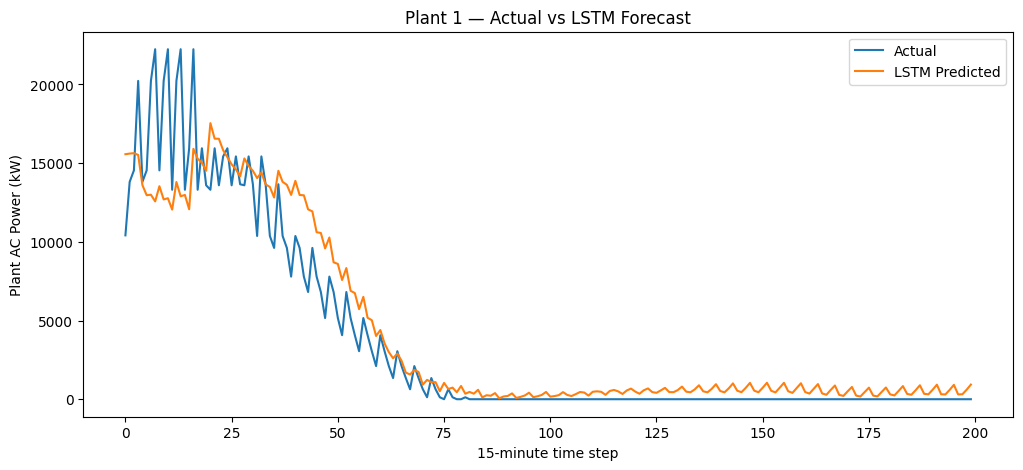

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_actual_kw[:200],
    label="Actual"
)

plt.plot(
    y_pred_kw[:200],
    label="LSTM Predicted"
)

plt.xlabel("15-minute time step")
plt.ylabel("Plant AC Power (kW)")
plt.title("Plant 1 — Actual vs LSTM Forecast")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Plant 2 files
generation2 = pd.read_csv("Plant_2_Generation_Data.csv")
weather2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

# Parse dates
generation2["DATE_TIME"] = pd.to_datetime(
    generation2["DATE_TIME"],
    dayfirst=True
)

weather2["DATE_TIME"] = pd.to_datetime(
    weather2["DATE_TIME"]
)

# Merge
data2 = pd.merge(
    generation2,
    weather2,
    on="DATE_TIME",
    how="inner",
    suffixes=("_gen", "_weather")
)

# Rename
data2 = data2.rename(columns={
    "PLANT_ID_gen": "PLANT_ID",
    "SOURCE_KEY_gen": "SOURCE_KEY"
})

# Create hour and keep daylight
data2["HOUR"] = data2["DATE_TIME"].dt.hour

daylight2 = data2[data2["AC_POWER"] > 0].copy()

# Same Model A features
features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "HOUR"
]

target = "AC_POWER"

X2 = daylight2[features]
y2 = daylight2[target]

# IMPORTANT:
# Fit scaler on Plant 1 training data, NOT Plant 2.
modelA_scaler = StandardScaler()
modelA_scaler.fit(train[features])

# Transform Plant 2 using Plant 1 scaler
X2_scaled = modelA_scaler.transform(X2)

print("Plant 2 rows:", len(daylight2))
print("X2 shape:", X2.shape)
print("X2_scaled shape:", X2_scaled.shape)

Plant 2 rows: 32036
X2 shape: (32036, 4)
X2_scaled shape: (32036, 4)


/tmp/ipykernel_5694/1623270986.py:9: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  generation2["DATE_TIME"] = pd.to_datetime(


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predict Plant 2 using the Plant 1-trained MLP
y2_pred = mlp.predict(X2_scaled)

# Calculate metrics
mae2 = mean_absolute_error(y2, y2_pred)
r2_2 = r2_score(y2, y2_pred)

print("Plant 2 Transfer Results")
print("MAE =", round(mae2, 4))
print("R²  =", round(r2_2, 4))

Plant 2 Transfer Results
MAE = 56.7166
R²  = 0.8856


In [ ]:
print("=" * 55)
print("MODEL A — PLANT 2 TRANSFER")
print("=" * 55)

print("Plant 1 MAE =", round(mae, 4))
print("Plant 1 R²  =", round(r2, 4))

print("Plant 2 MAE =", round(mae2, 4))
print("Plant 2 R²  =", round(r2_2, 4))

MODEL A — PLANT 2 TRANSFER
Plant 1 MAE = 26.2533
Plant 1 R²  = 0.9831
Plant 2 MAE = 56.7166
Plant 2 R²  = 0.8856


In [ ]:
print("=" * 65)
print("SOLAR PV DEEP LEARNING PROJECT — FINAL RESULTS")
print("=" * 65)

print("\nMODEL A — INVERTER AC POWER PREDICTION")
print("Plant 1 MAE :", round(mae, 4))
print("Plant 1 R²  :", round(r2, 4))

print("\nFAULT DETECTION")
print("Worst-performing inverter:", worst_inverter)
print("Mean error:", round(
    inverter_performance.loc[worst_inverter, "mean_error"], 4
))
print("Mean absolute error:", round(
    inverter_performance.loc[worst_inverter, "mean_abs_error"], 4
))

print("\nMODEL B — 1-HOUR PLANT FORECAST")
print("LSTM MAE        :", round(lstm_mae, 4))
print("Persistence MAE :", round(persistence_mae, 4))

print("\nPLANT 2 TRANSFER")
print("Plant 2 MAE :", round(mae2, 4))
print("Plant 2 R²  :", round(r2_2, 4))

SOLAR PV DEEP LEARNING PROJECT — FINAL RESULTS

MODEL A — INVERTER AC POWER PREDICTION
Plant 1 MAE : 26.2533
Plant 1 R²  : 0.9831

FAULT DETECTION
Worst-performing inverter: bvBOhCH3iADSZry
Mean error: -34.9204
Mean absolute error: 40.0287

MODEL B — 1-HOUR PLANT FORECAST
LSTM MAE        : 0.0559
Persistence MAE : 0.0622

PLANT 2 TRANSFER
Plant 2 MAE : 56.7166
Plant 2 R²  : 0.8856


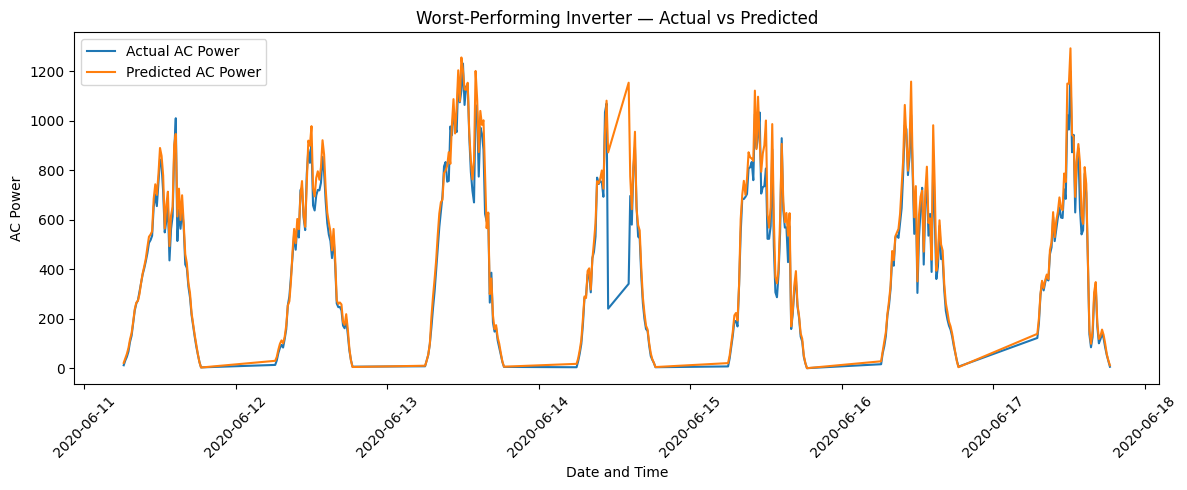

In [ ]:
import matplotlib.pyplot as plt

worst_data = test_results[
    test_results["SOURCE_KEY"] == worst_inverter
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["AC_POWER"],
    label="Actual AC Power"
)

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["PREDICTED_AC"],
    label="Predicted AC Power"
)

plt.xlabel("Date and Time")
plt.ylabel("AC Power")
plt.title("Worst-Performing Inverter — Actual vs Predicted")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Convert LSTM predictions back to original AC power scale

y_pred_lstm_original = scaler.inverse_transform(
    np.column_stack([
        y_pred_lstm[:, 0],
        np.zeros((len(y_pred_lstm), 3))
    ])
)[:, 0]

# Because we need all 4 future steps, inverse-transform each step separately
y_pred_lstm_original_all = []

for i in range(4):
    temp = np.zeros((len(y_pred_lstm), 4))
    temp[:, 0] = y_pred_lstm[:, i]
    converted = scaler.inverse_transform(temp)[:, 0]
    y_pred_lstm_original_all.append(converted)

y_pred_lstm_original_all = np.array(
    y_pred_lstm_original_all
).T

# Convert actual y values back to original AC power
y_test_original_all = []

for i in range(4):
    temp = np.zeros((len(y_test), 4))
    temp[:, 0] = y_test[:, i]
    converted = scaler.inverse_transform(temp)[:, 0]
    y_test_original_all.append(converted)

y_test_original_all = np.array(
    y_test_original_all
).T

# LSTM MAE in original units
lstm_mae_original = mean_absolute_error(
    y_test_original_all.flatten(),
    y_pred_lstm_original_all.flatten()
)

# Persistence in original units
persistence_original = np.zeros_like(y_test_original_all)

for i in range(4):
    temp = np.zeros((len(persistence_pred), 4))
    temp[:, 0] = persistence_pred[:, i]
    persistence_original[:, i] = scaler.inverse_transform(temp)[:, 0]

persistence_mae_original = mean_absolute_error(
    y_test_original_all.flatten(),
    persistence_original.flatten()
)

print("MODEL B — ORIGINAL AC POWER UNITS")
print("LSTM MAE        =", round(lstm_mae_original, 4))
print("Persistence MAE =", round(persistence_mae_original, 4))

if lstm_mae_original < persistence_mae_original:
    print("LSTM performs better than persistence.")
else:
    print("Persistence performs better than LSTM.")

MODEL B — ORIGINAL AC POWER UNITS
LSTM MAE        = 1630.6289
Persistence MAE = 1812.3053
LSTM performs better than persistence.


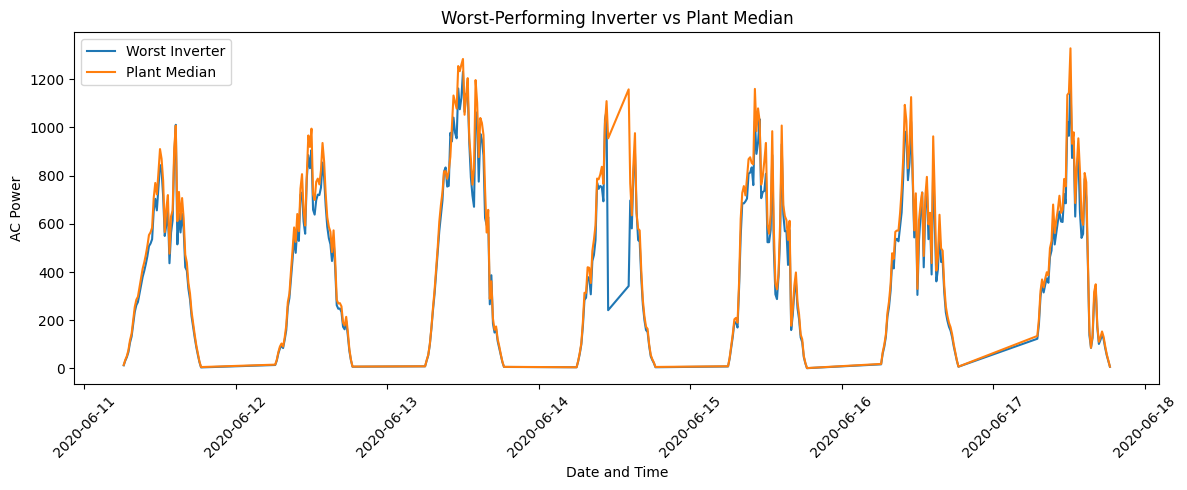

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate plant median AC power at each timestamp
plant_median = (
    test.groupby("DATE_TIME")["AC_POWER"]
    .median()
    .reset_index()
)

# 2. Select the worst-performing inverter
worst_data = test_results[
    test_results["SOURCE_KEY"] == worst_inverter
].copy()

# 3. Merge worst inverter with plant median
comparison = worst_data.merge(
    plant_median,
    on="DATE_TIME",
    suffixes=("_WORST", "_MEDIAN")
)

# 4. Plot
plt.figure(figsize=(12, 5))

plt.plot(
    comparison["DATE_TIME"],
    comparison["AC_POWER_WORST"],
    label="Worst Inverter"
)

plt.plot(
    comparison["DATE_TIME"],
    comparison["AC_POWER_MEDIAN"],
    label="Plant Median"
)

plt.xlabel("Date and Time")
plt.ylabel("AC Power")
plt.title(
    "Worst-Performing Inverter vs Plant Median"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# LSTM predictions
y_pred_lstm = model.predict(X_test, verbose=0)

# LSTM MAE
lstm_mae = mean_absolute_error(
    y_test.flatten(),
    y_pred_lstm.flatten()
)

# Persistence baseline:
# use the last observed plant AC power
persistence_pred = X_test[:, -1, 0]

# Repeat it for all 4 future steps
persistence_pred = np.repeat(
    persistence_pred.reshape(-1, 1),
    4,
    axis=1
)

# Persistence MAE
persistence_mae = mean_absolute_error(
    y_test.flatten(),
    persistence_pred.flatten()
)

print("=" * 55)
print("MODEL B — 1-HOUR PLANT FORECAST")
print("=" * 55)

print("LSTM MAE        =", round(lstm_mae, 4))
print("Persistence MAE =", round(persistence_mae, 4))

if lstm_mae < persistence_mae:
    print("\nLSTM performs better than the persistence baseline.")
else:
    print("\nPersistence performs better than LSTM.")

MODEL B — 1-HOUR PLANT FORECAST
LSTM MAE        = 0.0559
Persistence MAE = 0.0622

LSTM performs better than the persistence baseline.


In [ ]:
# AUTOENCODER — STEP 1
# Prepare Plant 1 daylight data for all inverters

ae_data = daylight.copy()

ae_features = [
    "IRRADIATION",
    "MODULE_TEMPERATURE",
    "AMBIENT_TEMPERATURE",
    "AC_POWER"
]

print("Autoencoder data shape:", ae_data.shape)
print("Number of inverters:", ae_data["SOURCE_KEY"].nunique())
print("Features:", ae_features)

print("\nMissing values:")
print(ae_data[ae_features].isnull().sum())

Autoencoder data shape: (36823, 14)
Number of inverters: 22
Features: ['IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE', 'AC_POWER']

Missing values:
IRRADIATION            0
MODULE_TEMPERATURE     0
AMBIENT_TEMPERATURE    0
AC_POWER               0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler for autoencoder
ae_scaler = StandardScaler()

# Scale the four features
ae_scaled = ae_scaler.fit_transform(
    ae_data[ae_features]
)

print("Scaled data shape:", ae_scaled.shape)
print("\nFirst 5 scaled rows:")
print(ae_scaled[:5])

Scaled data shape: (36823, 4)

First 5 scaled rows:
[[-1.48155033 -1.5741104  -1.10088304 -1.54337243]
 [-1.48155033 -1.5741104  -1.10088304 -1.53911236]
 [-1.48155033 -1.5741104  -1.10088304 -1.53796894]
 [-1.48155033 -1.5741104  -1.10088304 -1.53785315]
 [-1.48155033 -1.5741104  -1.10088304 -1.53887595]]


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Autoencoder architecture
input_dim = ae_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(8, activation="relu")(input_layer)
encoded = Dense(4, activation="relu")(encoded)

# Decoder
decoded = Dense(8, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)

# Create model
autoencoder = Model(input_layer, decoded)

# Compile
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Train
history_ae = autoencoder.fit(
    ae_scaled,
    ae_scaled,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

print("Autoencoder training completed.")

Epoch 1/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.9549 - val_loss: 0.4663
Epoch 2/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4334 - val_loss: 0.1609
Epoch 3/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1728 - val_loss: 0.0962
Epoch 4/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1019 - val_loss: 0.0465
Epoch 5/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0484 - val_loss: 0.0201
Epoch 6/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0247 - val_loss: 0.0147
Epoch 7/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0182 - val_loss: 0.0124
Epoch 8/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - val_loss: 0.0111
Epoch 9/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0140 - val_loss: 0.0101
Epoch 10/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0126 - val_loss: 0.0090
Epoch 11/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0115 - val_loss: 0.0081
Epoch 12/30
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [ ]:
# AUTOENCODER — STEP 4
# Calculate reconstruction error for every row

# Reconstruct the input data
ae_reconstructed = autoencoder.predict(
    ae_scaled,
    verbose=0
)

# Mean squared reconstruction error for each row
reconstruction_error = np.mean(
    np.square(ae_scaled - ae_reconstructed),
    axis=1
)

# Add error to the dataframe
ae_data = ae_data.copy()

ae_data["RECONSTRUCTION_ERROR"] = reconstruction_error

print("Reconstruction error calculated.")

print("\nFirst 5 rows:")
print(
    ae_data[
        ["SOURCE_KEY", "AC_POWER", "RECONSTRUCTION_ERROR"]
    ].head()
)

Reconstruction error calculated.

First 5 rows:
          SOURCE_KEY  AC_POWER  RECONSTRUCTION_ERROR
510  1BY6WEcLGh8j5v7  3.585714              0.000401
511  1IF53ai7Xc0U56Y  5.162500              0.000437
512  3PZuoBAID5Wc2HD  5.585714              0.000447
513  7JYdWkrLSPkdwr4  5.628571              0.000448
514  McdE0feGgRqW7Ca  5.250000              0.000439


In [ ]:
# Calculate average reconstruction error for each inverter

ae_inverter_performance = (
    ae_data
    .groupby("SOURCE_KEY")
    .agg(
        mean_reconstruction_error=(
            "RECONSTRUCTION_ERROR",
            "mean"
        ),
        actual_mean_power=("AC_POWER", "mean")
    )
    .sort_values(
        "mean_reconstruction_error",
        ascending=False
    )
)

print("=" * 65)
print("AUTOENCODER — INVERTER ANOMALY RANKING")
print("=" * 65)

print(ae_inverter_performance)

AUTOENCODER — INVERTER ANOMALY RANKING
                 mean_reconstruction_error  actual_mean_power
SOURCE_KEY                                                   
1BY6WEcLGh8j5v7                   0.007948         534.457701
bvBOhCH3iADSZry                   0.007313         526.999125
WRmjgnKYAwPKWDb                   0.005898         575.785936
3PZuoBAID5Wc2HD                   0.005485         587.712872
z9Y9gH1T5YWrNuG                   0.005398         573.243277
McdE0feGgRqW7Ca                   0.005199         585.370351
uHbuxQJl8lW7ozc                   0.005195         582.267151
pkci93gMrogZuBj                   0.005082         576.710021
adLQvlD726eNBSB                   0.005049         594.168012
wCURE6d3bPkepu2                   0.005034         578.567205
VHMLBKoKgIrUVDU                   0.004980         586.433513
rGa61gmuvPhdLxV                   0.004738         575.578222
ZnxXDlPa8U1GXgE                   0.004696         583.319998
1IF53ai7Xc0U56Y                

In [ ]:
# Compare the MLP worst inverter with the plant median

worst_inverter = "bvBOhCH3iADSZry"

# Calculate median AC power at each timestamp across all inverters
plant_median = (
    ae_data
    .groupby("DATE_TIME")["AC_POWER"]
    .median()
    .rename("PLANT_MEDIAN_AC")
)

# Select worst inverter data
worst_data = ae_data[
    ae_data["SOURCE_KEY"] == worst_inverter
].copy()

# Merge plant median
worst_data = worst_data.merge(
    plant_median,
    left_on="DATE_TIME",
    right_index=True,
    how="left"
)

# Difference from plant median
worst_data["MEDIAN_DIFFERENCE"] = (
    worst_data["AC_POWER"]
    - worst_data["PLANT_MEDIAN_AC"]
)

worst_data["ABS_MEDIAN_DIFFERENCE"] = (
    worst_data["MEDIAN_DIFFERENCE"].abs()
)

print("=" * 65)
print("WORST INVERTER vs PLANT MEDIAN")
print("=" * 65)

print("Worst inverter:", worst_inverter)

print("\nMean actual AC power:")
print(round(worst_data["AC_POWER"].mean(), 4))

print("\nMean plant median AC power:")
print(round(worst_data["PLANT_MEDIAN_AC"].mean(), 4))

print("\nMean difference from plant median:")
print(round(worst_data["MEDIAN_DIFFERENCE"].mean(), 4))

print("\nMean absolute difference:")
print(round(worst_data["ABS_MEDIAN_DIFFERENCE"].mean(), 4))

WORST INVERTER vs PLANT MEDIAN
Worst inverter: bvBOhCH3iADSZry

Mean actual AC power:
526.9991

Mean plant median AC power:
572.4267

Mean difference from plant median:
-45.4276

Mean absolute difference:
49.9203


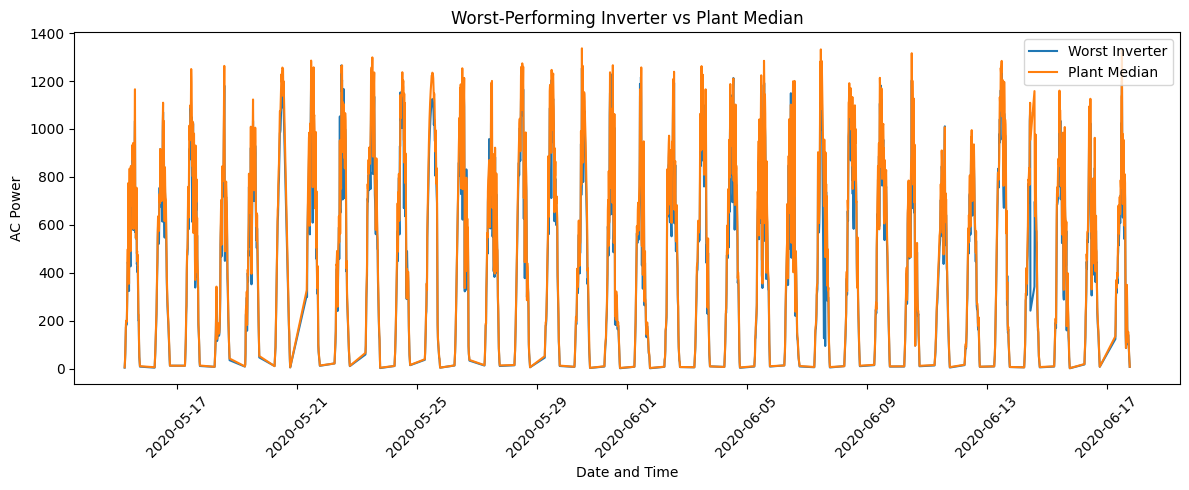

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["AC_POWER"],
    label="Worst Inverter"
)

plt.plot(
    worst_data["DATE_TIME"],
    worst_data["PLANT_MEDIAN_AC"],
    label="Plant Median"
)

plt.xlabel("Date and Time")
plt.ylabel("AC Power")
plt.title("Worst-Performing Inverter vs Plant Median")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("PROJECT COMPLETED")
print("Model A — MLP: Completed")
print("Model B — LSTM vs Persistence: Completed")
print("Plant 2 Transfer: Completed")
print("Autoencoder: Completed")
print("Worst Inverter vs Plant Median: Completed")

PROJECT COMPLETED
Model A — MLP: Completed
Model B — LSTM vs Persistence: Completed
Plant 2 Transfer: Completed
Autoencoder: Completed
Worst Inverter vs Plant Median: Completed
